In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("cleaned_reviews.csv")
df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.date

print("Date range in data:", df['day'].min(), "to", df['day'].max())
print("Total unique days:", df['day'].nunique())

Date range in data: 2024-11-12 to 2026-06-18
Total unique days: 584


In [2]:
# Daily sentiment counts per brand
daily_stats = df.groupby(['brand', 'day']).agg(
    total_reviews = ('review_id', 'count'),
    avg_rating = ('rating', 'mean'),
    negative_count = ('sentiment', lambda x: (x == 'Negative').sum()),
).reset_index()

daily_stats['negative_ratio'] = daily_stats['negative_count'] / daily_stats['total_reviews']

print("Sample daily stats:")
print(daily_stats.head(10))
print("\nTotal rows:", len(daily_stats))

Sample daily stats:
     brand         day  total_reviews  avg_rating  negative_count  \
0  Blinkit  2026-05-17            414    3.847826             105   
1  Blinkit  2026-05-18           2132    4.059099             414   
2  Blinkit  2026-05-19           1672    4.066388             314   
3  Blinkit  2026-05-20           1609    4.034804             317   
4  Blinkit  2026-05-21           1514    4.095773             281   
5  Blinkit  2026-05-22           1510    4.076821             279   
6  Blinkit  2026-05-23           1439    4.070883             273   
7  Blinkit  2026-05-24           1929    4.128046             325   
8  Blinkit  2026-05-25           1477    4.091401             267   
9  Blinkit  2026-05-26           1459    4.058944             284   

   negative_ratio  
0        0.253623  
1        0.194184  
2        0.187799  
3        0.197017  
4        0.185601  
5        0.184768  
6        0.189715  
7        0.168481  
8        0.180772  
9        0.194654  


In [3]:
print("Date range per brand:")
print(df.groupby('brand')['day'].agg(['min', 'max', 'nunique']))

Date range per brand:
                min         max  nunique
brand                                   
Blinkit  2026-05-17  2026-06-18       33
CRED     2024-11-12  2026-06-18      584
Meesho   2026-03-30  2026-06-18       81
Ola      2024-12-22  2026-06-18      544
Paytm    2026-01-12  2026-06-18      158
PhonePe  2026-03-25  2026-06-18       86
Swiggy   2026-03-01  2026-06-18      110
Uber     2026-03-08  2026-06-18      103
Zepto    2025-11-09  2026-06-18      222
Zomato   2026-05-04  2026-06-18       46


In [4]:
from sklearn.ensemble import IsolationForest

# Only keep brands with enough days to detect meaningful anomalies
valid_brands = df.groupby('brand')['day'].nunique()
valid_brands = valid_brands[valid_brands >= 30].index.tolist()
print("Brands with enough data for anomaly detection:", valid_brands)

daily_stats_filtered = daily_stats[daily_stats['brand'].isin(valid_brands)].copy()

# Train one Isolation Forest per brand (since scale of reviews/day differs a lot)
anomaly_results = []

for brand in valid_brands:
    brand_data = daily_stats_filtered[daily_stats_filtered['brand'] == brand].copy()
    features = brand_data[['total_reviews', 'avg_rating', 'negative_ratio']]
    
    iso = IsolationForest(contamination=0.1, random_state=42)
    brand_data['anomaly'] = iso.fit_predict(features)
    brand_data['anomaly_label'] = brand_data['anomaly'].map({1: 'Normal', -1: 'Crisis Alert'})
    
    anomaly_results.append(brand_data)

final_anomaly_df = pd.concat(anomaly_results, ignore_index=True)

print("\nCrisis days detected per brand:")
print(final_anomaly_df[final_anomaly_df['anomaly_label'] == 'Crisis Alert'].groupby('brand').size())

Brands with enough data for anomaly detection: ['Blinkit', 'CRED', 'Meesho', 'Ola', 'Paytm', 'PhonePe', 'Swiggy', 'Uber', 'Zepto', 'Zomato']

Crisis days detected per brand:
brand
Blinkit     4
CRED       59
Meesho      8
Ola        55
Paytm      16
PhonePe     9
Swiggy     11
Uber       11
Zepto      23
Zomato      5
dtype: int64


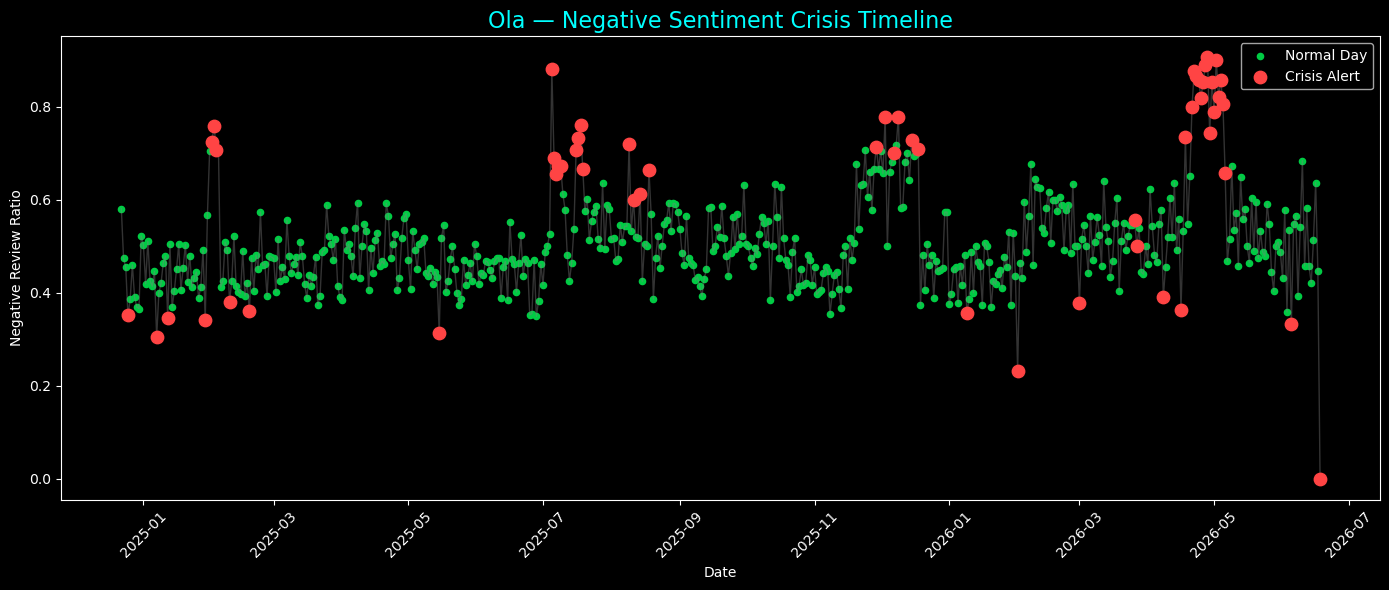

In [5]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')

brand_to_plot = 'Ola'
plot_data = final_anomaly_df[final_anomaly_df['brand'] == brand_to_plot].sort_values('day')

fig, ax = plt.subplots(figsize=(14, 6))

normal = plot_data[plot_data['anomaly_label'] == 'Normal']
crisis = plot_data[plot_data['anomaly_label'] == 'Crisis Alert']

ax.plot(plot_data['day'], plot_data['negative_ratio'], color='gray', alpha=0.4, linewidth=1)
ax.scatter(normal['day'], normal['negative_ratio'], color='#00cc44', s=20, label='Normal Day')
ax.scatter(crisis['day'], crisis['negative_ratio'], color='#ff4444', s=80, label='Crisis Alert', zorder=5)

ax.set_title(f'{brand_to_plot} — Negative Sentiment Crisis Timeline', color='cyan', fontsize=16)
ax.set_xlabel('Date', color='white')
ax.set_ylabel('Negative Review Ratio', color='white')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crisis_timeline_ola.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
pickle.dump(iso, open('isolation_forest_model.pkl', 'wb'))
final_anomaly_df.to_csv('anomaly_results.csv', index=False)
print("Saved isolation_forest_model.pkl and anomaly_results.csv")

Saved isolation_forest_model.pkl and anomaly_results.csv
